In [19]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("youtube recommendation dataset.csv")
df

,user_id,video_id,video_duration,watch_time,liked,commented,subscribed_after,category,device,watch_time_of_day,recommended,clicked,timestamp,watch_percent
0,88263,19387,1499,1499.0,1,0,0,News,TV,Night,0,0,2025-07-16 06:10:54,1.000000
1,46796,5150,2955,2955.0,1,0,0,Education,Mobile,Night,1,1,2024-07-09 10:22:22,1.000000
2,77686,3172,389,389.0,0,0,0,Sports,Desktop,Afternoon,0,0,2025-02-07 09:46:36,1.000000
3,26723,27669,1231,1231.0,1,1,0,Gaming,TV,Evening,0,0,2024-04-28 08:07:13,1.000000
4,55299,24612,3573,353.0,0,1,0,Lifestyle,Desktop,Evening,1,0,2024-03-30 12:54:24,0.098797
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,30850,24888,2390,1902.0,0,0,0,Sports,Tablet,Morning,0,0,2024-01-09 16:41:36,0.795816
999996,14324,3681,311,311.0,1,0,0,Education,TV,Evening,0,0,2024-03-14 22:22:54,1.000000
999997,963,11107,2472,2472.0,1,0,0,Tech,Tablet,Evening,0,0,2023-09-06 08:54:24,1.000000
999998,87484,40134,1725,1725.0,0,0,1,News,Mobile,Night,1,0,2025-03-28 01:31:39,1.000000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 14 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   user_id            1000000 non-null  int64  
 1   video_id           1000000 non-null  int64  
 2   video_duration     1000000 non-null  int64  
 3   watch_time         1000000 non-null  float64
 4   liked              997952 non-null   object 
 5   commented          1000000 non-null  int64  
 6   subscribed_after   1000000 non-null  int64  
 7   category           1000000 non-null  object 
 8   device             1000000 non-null  object 
 9   watch_time_of_day  1000000 non-null  object 
 10  recommended        1000000 non-null  int64  
 11  clicked            1000000 non-null  int64  
 12  timestamp          1000000 non-null  object 
 13  watch_percent      1000000 non-null  float64
dtypes: float64(2), int64(7), object(5)
memory usage: 106.8+ MB


In [4]:
df.describe()

,user_id,video_id,video_duration,watch_time,commented,subscribed_after,recommended,clicked,watch_percent
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1.000000e+06
mean,50014.595087,25008.932584,1911.577131,1283.683469,0.099497,0.050004,0.399768,0.300771,inf
std,28864.277887,14434.546717,3270.284893,2499.074293,0.299328,0.217953,0.489851,0.458594,NaN
min,1.000000,1.000000,0.000000,-299.000000,0.000000,0.000000,0.000000,0.000000,-2.990000e-03
25%,24998.000000,12503.000000,921.000000,498.000000,0.000000,0.000000,0.000000,0.000000,4.990537e-01
50%,50048.000000,25020.000000,1816.000000,1071.000000,0.000000,0.000000,0.000000,0.000000,9.963570e-01
75%,75022.000000,37522.000000,2710.000000,1821.000000,0.000000,0.000000,1.000000,1.000000,1.000000e+00
max,100000.000000,50000.000000,100000.000000,109969.000000,1.000000,1.000000,1.000000,1.000000,inf


In [5]:
df.drop(columns = ["user_id",'video_id',],inplace = True)
df.head()

,video_duration,watch_time,liked,commented,subscribed_after,category,device,watch_time_of_day,recommended,clicked,timestamp,watch_percent
0,1499,1499.0,1,0,0,News,TV,Night,0,0,2025-07-16 06:10:54,1.000000
1,2955,2955.0,1,0,0,Education,Mobile,Night,1,1,2024-07-09 10:22:22,1.000000
2,389,389.0,0,0,0,Sports,Desktop,Afternoon,0,0,2025-02-07 09:46:36,1.000000
3,1231,1231.0,1,1,0,Gaming,TV,Evening,0,0,2024-04-28 08:07:13,1.000000
4,3573,353.0,0,1,0,Lifestyle,Desktop,Evening,1,0,2024-03-30 12:54:24,0.098797


In [6]:
df.isnull().sum()

video_duration          0
watch_time              0
liked                2048
commented               0
subscribed_after        0
category                0
device                  0
watch_time_of_day       0
recommended             0
clicked                 0
timestamp               0
watch_percent           0
dtype: int64

In [9]:
df.liked.value_counts()

liked
0      696155
1      298845
2        1007
no        988
yes       957
Name: count, dtype: int64

In [10]:
df = df[df['liked'] != 'no']
df = df[df['liked'] != 'yes']
df['liked'].fillna(0,inplace= True)
df.isnull().sum()

/var/folders/cn/typknvzx0rqc0bg_wj2zt_t00000gn/T/ipykernel_5592/2652148681.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['liked'].fillna(0,inplace= True)


video_duration       0
watch_time           0
liked                0
commented            0
subscribed_after     0
category             0
device               0
watch_time_of_day    0
recommended          0
clicked              0
timestamp            0
watch_percent        0
dtype: int64

In [13]:
df.video_duration.unique()

array([1499, 2955,  389, ..., 1746,  387, 1786], shape=(3572,))

In [14]:
df.watch_time.unique()

array([1499., 2955.,  389., ..., 4466., 9012., 8754.], shape=(5781,))

In [15]:
df.category.unique()

array(['News', 'Education', 'Sports', 'Gaming', 'Lifestyle', 'Music',
       'Tech', 'Comedy', 'gamingg', 'MUsic', 'music', 'Ed', 'COMEDY',
       'Tech '], dtype=object)

In [16]:
df.device.unique()

array(['TV', 'Mobile', 'Desktop', 'Tablet'], dtype=object)

In [17]:
df.watch_time_of_day.unique()

array(['Night', 'Afternoon', 'Evening', 'Morning'], dtype=object)

In [18]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.describe()

,video_duration,watch_time,commented,subscribed_after,recommended,clicked,watch_percent
count,998055.000000,998055.000000,998055.000000,998055.000000,998055.000000,998055.000000,9.980550e+05
mean,1872.975800,1254.228955,0.099492,0.050007,0.399772,0.300779,inf
std,2616.448503,1982.487220,0.299321,0.217960,0.489852,0.458597,NaN
min,0.000000,-299.000000,0.000000,0.000000,0.000000,0.000000,-2.990000e-03
25%,921.000000,498.000000,0.000000,0.000000,0.000000,0.000000,4.984810e-01
50%,1815.000000,1069.000000,0.000000,0.000000,0.000000,0.000000,9.949087e-01
75%,2710.000000,1817.000000,0.000000,0.000000,1.000000,1.000000,1.000000e+00
max,100000.000000,109969.000000,1.000000,1.000000,1.000000,1.000000,inf


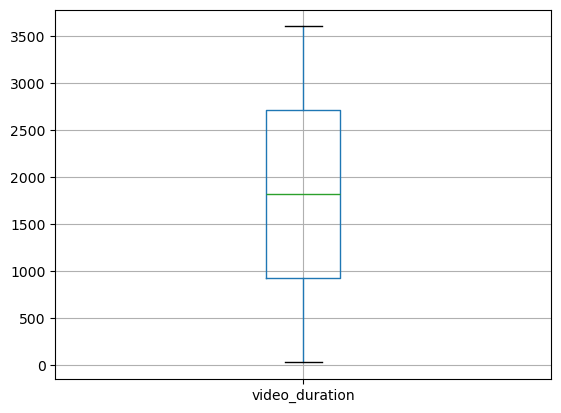

In [30]:
df.boxplot(column=['video_duration'])
plt.show()

In [24]:
import numpy as np

# Select numerical columns
num_cols = df.select_dtypes(include=np.number).columns

# Remove outliers using IQR
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print("Shape after removing outliers:", df.shape)

Shape after removing outliers: (851439, 12)


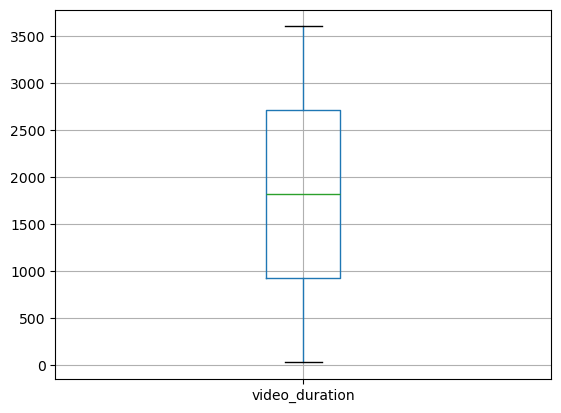

In [29]:
df.boxplot(column=['video_duration'])
plt.show()


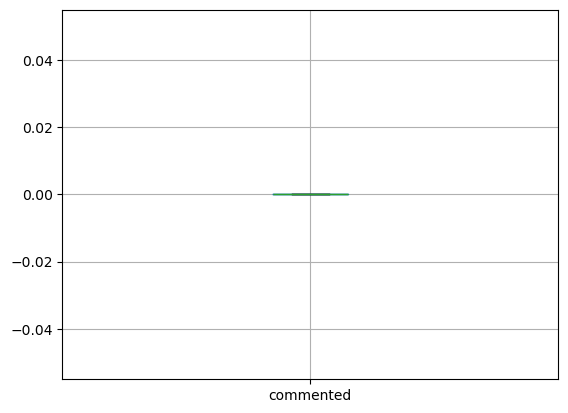

In [31]:
df.watch_percent.unique()

array([1.        , 0.02134472, 0.12577904, ..., 0.11171848, 0.75108091,
       0.7958159 ], shape=(376978,))